In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import scipy.optimize as sco
import os
from datetime import datetime, timedelta

In [81]:
DATA_FILE = r"stocks_python.xlsx"
OUTPUT_FOLDER = r"Portfolio_Optimization"
SELECTED_INDICES_NAMES = ['SBER', 'FLOT', 'IRAO', 'NVTK', 'PHOR', 'MGNT', 'CHMF']
START_DATE_STR = "2021-01-04"
FORECAST_START_DATE_STR = "2025-12-01"
END_DATE_STR = None
FORECAST_YEARS = 20
MIN_ALLOCATION = 0.05
MAX_ALLOCATION = 0.25
NUM_SIMULATIONS = 100000
INITIAL_DEPOSIT = 144637500
ANNUAL_CONTRIBUTION = 45080000
REBALANCING_ENABLED = True
RISK_AVERSION_DECAY = 0.95
DIVIDEND_YIELDS = {
    'SBER': 0.0801,    
    'FLOT': 0.0587,   
    'IRAO': 0.0741,    
    'NVTK': 0.0646,   
    'PHOR': 0.1141,    
    'MGNT': 0.0484,    
    'CHMF': 0.0734,   
}
risk_free_rate = 0.1361


In [82]:
def load_data(file_path, sheet_name="DATA"):
    try:
        df = pd.read_excel(file_path, sheet_name=sheet_name, index_col=0, parse_dates=True)
        return df
    except FileNotFoundError:
        print(f"Ошибка: Файл '{file_path}' не найден.")
        return None
    except Exception as e:
        print(f"Ошибка при загрузке данных: {e}")
        return None

In [83]:
def select_indices(df, selected_indices_names):
    available_indices = df.columns.tolist()
    selected_indices = [index for index in selected_indices_names if index in available_indices]
    if not selected_indices:
        print(f"В файле не найден ни один из указанных индексов: {selected_indices_names}. Доступные индексы: {available_indices}")
        return None
    return df[selected_indices]

In [84]:
def select_date_range(df, start_date_str=None, end_date_str=None):
    start_date = datetime.strptime(start_date_str, '%Y-%m-%d').date() if start_date_str else df.index.min().date()
    end_date = datetime.strptime(end_date_str, '%Y-%m-%d').date() if end_date_str else df.index.max().date()
    if start_date <= end_date:
        return df[(df.index.date >= start_date) & (df.index.date <= end_date)]
    else:
        print("Начальная дата не может быть позже конечной.")
        return None

In [85]:
def calculate_returns(df):
    price_returns = df.pct_change()
    dividend_daily = {}
    for ticker in df.columns:
        if ticker in DIVIDEND_YIELDS:
            annual_yield = DIVIDEND_YIELDS[ticker]
            daily_yield = (1 + annual_yield) ** (1/252) - 1
            dividend_daily[ticker] = daily_yield
        else:
            dividend_daily[ticker] = 0
    dividend_df = pd.DataFrame(
        np.full_like(price_returns.values, list(dividend_daily.values())),
        index=price_returns.index,
        columns=price_returns.columns
    )
    total_returns = price_returns + dividend_df
    return total_returns.dropna()

In [86]:
def portfolio_annualised_performance(weights, mean_returns, cov_matrix):
    returns = np.sum(mean_returns * weights) * 252
    std_dev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights))) * np.sqrt(252)
    return std_dev, returns

In [87]:
def neg_sharpe_ratio(weights, mean_returns, cov_matrix, risk_free_rate):
    p_var, p_ret = portfolio_annualised_performance(weights, mean_returns, cov_matrix)
    return -(p_ret - risk_free_rate) / p_var

In [88]:
def efficient_frontier(returns, risk_free_rate, num_portfolios=10000):
    mean_returns = returns.mean()
    cov_matrix = returns.cov()
    num_assets = len(returns.columns)
    results = np.zeros((3, num_portfolios))
    for i in range(num_portfolios):
        weights = np.random.random(num_assets)
        weights /= np.sum(weights)
        p_vol, p_ret = portfolio_annualised_performance(weights, mean_returns, cov_matrix)
        results[0, i] = p_vol
        results[1, i] = p_ret
        results[2, i] = (p_ret - risk_free_rate) / p_vol
    return results

In [89]:
def markowitz_optimization(returns, risk_free_rate, bounds=(0, 1)):
    mean_returns = returns.mean()
    cov_matrix = returns.cov()
    num_assets = len(returns.columns)
    args = (mean_returns, cov_matrix)
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple(bounds for asset in range(num_assets))

    def minimize_volatility(weights, mean_returns, cov_matrix):
        return portfolio_annualised_performance(weights, mean_returns, cov_matrix)[0]

    opt_vol = sco.minimize(minimize_volatility, np.array([1/num_assets]*num_assets), args=args, method='SLSQP', bounds=bounds, constraints=constraints)

    def minimize_neg_sharpe(weights, mean_returns, cov_matrix, risk_free_rate):
        return neg_sharpe_ratio(weights, mean_returns, cov_matrix, risk_free_rate)

    opt_sharpe = sco.minimize(minimize_neg_sharpe, np.array([1/num_assets]*num_assets), args=(mean_returns, cov_matrix, risk_free_rate), method='SLSQP', bounds=bounds, constraints=constraints)

    return opt_vol, opt_sharpe

In [90]:
def monte_carlo_simulation(returns, risk_free_rate, num_simulations=100000, bounds=(0, 1)):
    mean_returns = returns.mean()
    cov_matrix = returns.cov()
    num_assets = len(returns.columns)
    results = np.zeros((3 + num_assets, num_simulations))

    for i in range(num_simulations):
        weights = np.random.uniform(bounds[0], bounds[1], num_assets)
        weights /= np.sum(weights)
        p_vol, p_ret = portfolio_annualised_performance(weights, mean_returns, cov_matrix)
        results[0, i] = p_vol
        results[1, i] = p_ret
        results[2, i] = (p_ret - risk_free_rate) / p_vol
        results[3:, i] = weights

    return results

In [91]:
def calculate_max_drawdown(portfolio_values):
    peak = portfolio_values[0]
    max_drawdown = 0
    for value in portfolio_values:
        if value > peak:
            peak = value
        drawdown = (peak - value) / peak
        if drawdown > max_drawdown:
            max_drawdown = drawdown
    return max_drawdown

In [92]:
def plot_portfolio_forecast(portfolio_values, dates, title, output_path):
    plt.figure(figsize=(12, 6))
    plt.plot(dates, portfolio_values)
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xlabel('Дата')
    plt.ylabel('Стоимость портфеля')
    plt.title(title)
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(output_path)
    plt.show()

In [93]:
def plot_efficient_frontier_and_portfolios(monte_carlo_results, mean_weights, min_vol_port, max_sharpe_port, output_path):
    plt.figure(figsize=(12, 8))
    plt.scatter(monte_carlo_results[0,:], monte_carlo_results[1,:], c=monte_carlo_results[2,:], marker='o', cmap='viridis')
    plt.colorbar(label='Коэффициент Шарпа')
    plt.xlabel('Годовая волатильность')
    plt.ylabel('Годовая доходность')
    plt.title('Облако портфелей (Монте-Карло)')

    mean_vol, mean_ret = portfolio_annualised_performance(mean_weights['weights'], returns.mean(), returns.cov())
    plt.scatter(mean_vol, mean_ret, marker='X', color='r', s=200, label='Средние доли')

    min_vol, min_ret = min_vol_port['fun'], portfolio_annualised_performance(min_vol_port['x'], returns.mean(), returns.cov())[1]
    plt.scatter(min_vol, min_ret, marker='*', color='g', s=200, label='Мин. риск')

    max_sharpe_vol, max_sharpe_ret = portfolio_annualised_performance(max_sharpe_port['x'], returns.mean(), returns.cov())
    plt.scatter(max_sharpe_vol, max_sharpe_ret, marker='P', color='gold', s=200, label='Макс. Sharpe')

    plt.legend()
    plt.grid(True)
    plt.savefig(output_path)
    plt.show()

In [94]:
def plot_portfolio_structure(weights_history, dates, assets, output_path):
    plt.figure(figsize=(12, 6))
    plt.stackplot(dates, np.array(weights_history).T, labels=assets)
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xlabel('Дата')
    plt.ylabel('Доля в портфеле')
    plt.title('Изменение структуры портфеля')
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(output_path)
    plt.show()

In [95]:
def forecast_portfolio(initial_investment, annual_contribution, years, returns_data, weights, start_date, model="historical"):
    portfolio_value = initial_investment
    portfolio_values = [portfolio_value]
    dates = [start_date]
    yearly_results = []

    if model == "historical":
        annual_returns = returns_data.resample('YE').sum()
        for year in range(years):
            annual_return = np.sum(annual_returns.sample(n=1).iloc[0] * weights)
            portfolio_value += annual_contribution
            portfolio_value *= (1 + annual_return)
            portfolio_values.append(portfolio_value)
            dates.append(start_date + timedelta(days=365*(year+1)))
            yearly_results.append({"Год": start_date.year + year + 1, "Доходность": annual_return, "Стоимость портфеля": portfolio_value})

    return portfolio_values, dates, yearly_results

In [96]:
def rebalance_portfolio(initial_investment, annual_contribution, years, returns_data, initial_weights, risk_aversion_decay, start_date=None, model="historical"):
    num_assets = len(initial_weights)
    portfolio_value = initial_investment
    results = []
    current_weights = np.array(initial_weights)
    asset_volatility = returns_data.std() * np.sqrt(252)
    risk_ranking = np.argsort(asset_volatility).values
    dates = [start_date]
    portfolio_values = [portfolio_value]
    weights_history = [current_weights.copy()]
    yearly_results = []


    for year in range(years):
        if model == "historical":
            annual_returns_rebalance = returns_data.resample('YE').sum()
            annual_return = np.sum(annual_returns_rebalance.sample(n=1).iloc[0] * current_weights)

        portfolio_value += annual_contribution
        portfolio_value *= (1 + annual_return)
        results.append((year+1, portfolio_value, current_weights))
        dates.append(start_date + timedelta(days=365*(year+1)))
        portfolio_values.append(portfolio_value)
        yearly_results.append({"Год": start_date.year + year + 1, "Доходность": annual_return, "Стоимость портфеля": portfolio_value, "Веса": current_weights.copy()})  # Add this


        riskiest_asset_index = risk_ranking[-1]
        weight_reduction = current_weights[riskiest_asset_index] * (1 - risk_aversion_decay)
        current_weights[riskiest_asset_index] -= weight_reduction

        least_risky_asset_index = risk_ranking[0]
        current_weights[least_risky_asset_index] += weight_reduction

        current_weights /= np.sum(current_weights)
        asset_volatility = returns_data.std() * np.sqrt(252)
        risk_ranking = np.argsort(asset_volatility).values
        weights_history.append(current_weights.copy())

    return portfolio_values, dates, weights_history, yearly_results 

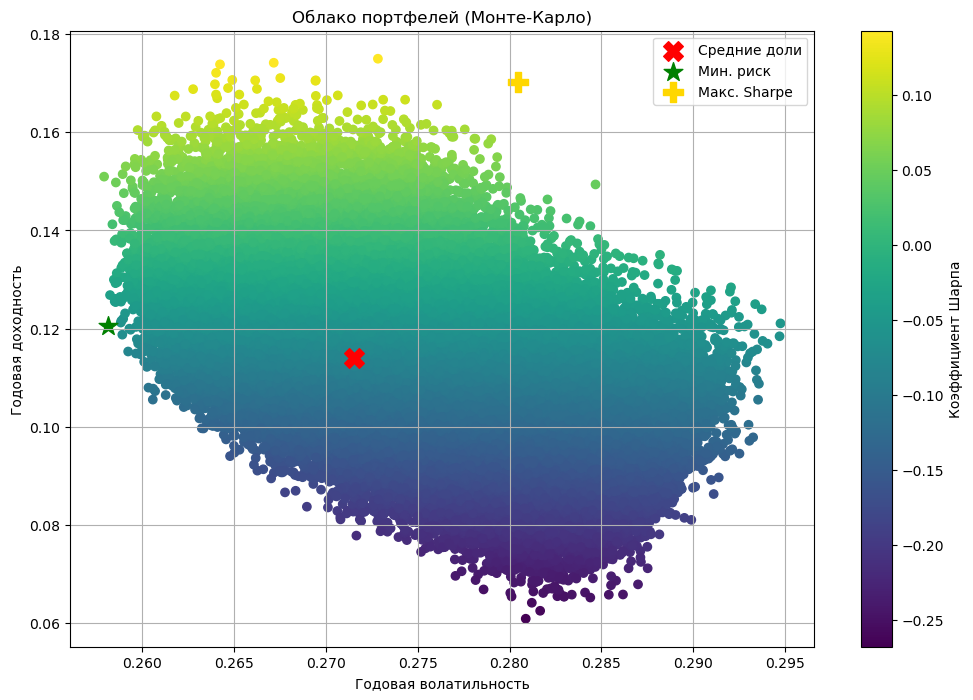

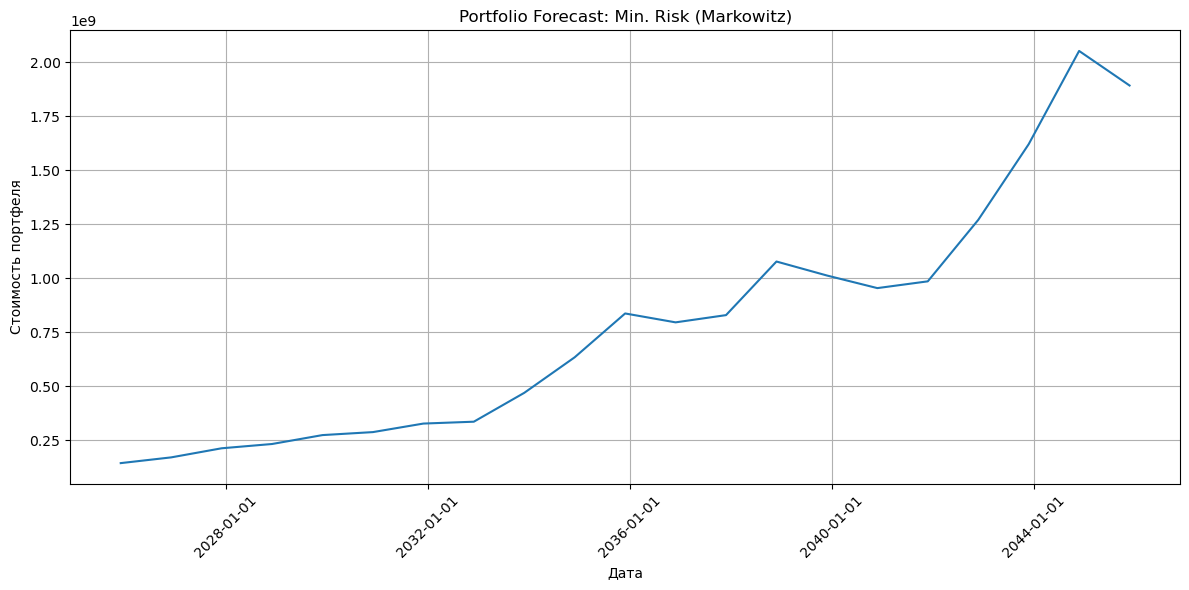

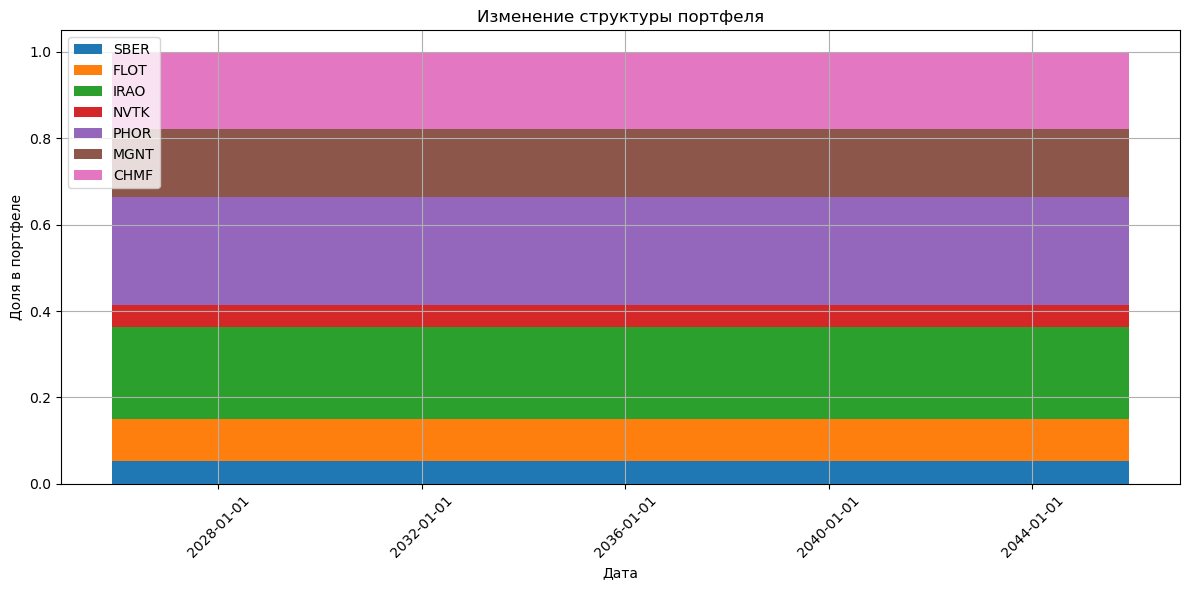

Max Drawdown (Min. Risk (Markowitz)): 11.42%

Min. Risk (Markowitz):
 Год  Доходность  Стоимость портфеля
2026   -0.097768        1.711693e+08
2027   -0.013769        2.132717e+08
2028   -0.097768        2.330933e+08
2029   -0.013769        2.743430e+08
2030   -0.097768        2.881938e+08
2031   -0.016819        3.276686e+08
2032   -0.097768        3.363059e+08
2033    0.232076        4.698965e+08
2034    0.232076        6.344902e+08
2035    0.232076        8.372822e+08
2036   -0.097768        7.960958e+08
2037   -0.013769        8.295935e+08
2038    0.232076        1.077664e+09
2039   -0.097768        1.012976e+09
2040   -0.097768        9.546127e+08
2041   -0.013769        9.859277e+08
2042    0.232076        1.270280e+09
2043    0.232076        1.620624e+09
2044    0.232076        2.052274e+09
2045   -0.097768        1.892301e+09


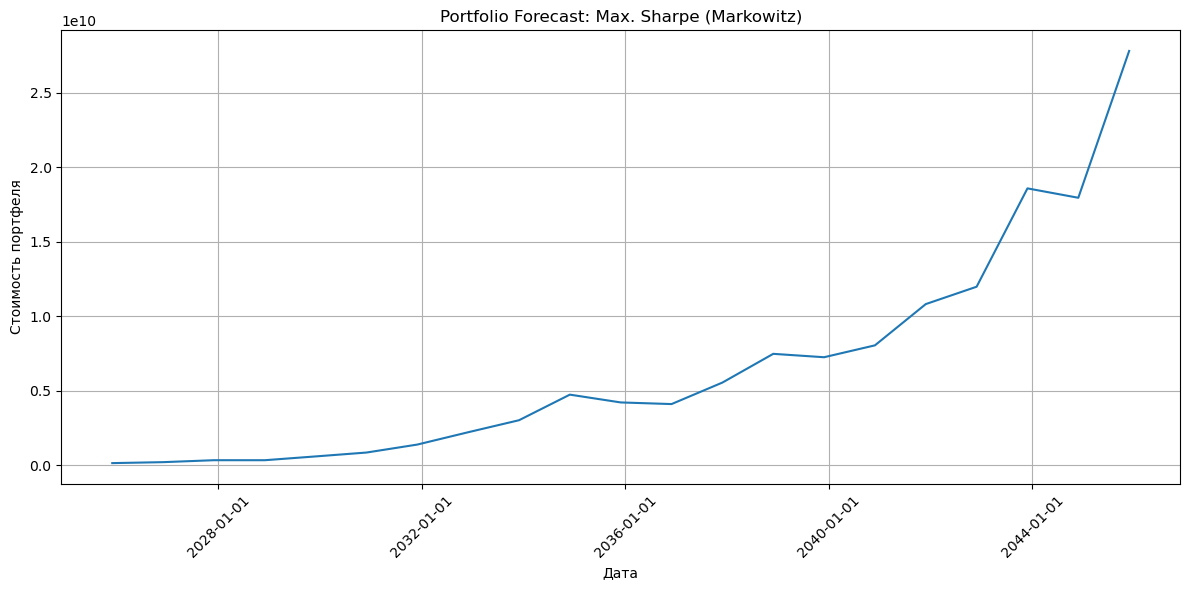

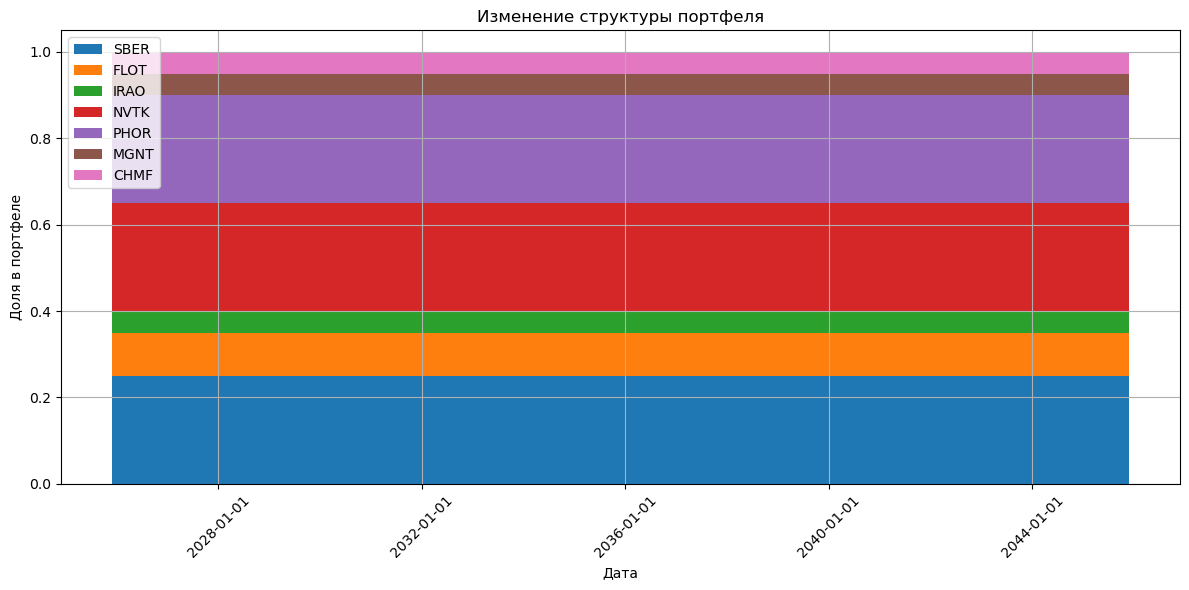

Max Drawdown (Max. Sharpe (Markowitz)): 13.35%

Max. Sharpe (Markowitz):
 Год  Доходность  Стоимость портфеля
2026    0.103112        2.092797e+08
2027    0.336559        3.399668e+08
2028   -0.118771        3.393144e+08
2029    0.545026        5.938994e+08
2030    0.336559        8.540340e+08
2031    0.545026        1.389155e+09
2032    0.545026        2.215930e+09
2033    0.336559        3.021975e+09
2034    0.545026        4.738680e+09
2035   -0.118771        4.215588e+09
2036   -0.036262        4.106166e+09
2037    0.336559        5.548386e+09
2038    0.336559        7.476000e+09
2039   -0.036262        7.248348e+09
2040    0.103112        8.045469e+09
2041    0.336559        1.081350e+10
2042    0.103112        1.197823e+10
2043    0.545026        1.857633e+10
2044   -0.036262        1.794616e+10
2045    0.545026        2.779693e+10


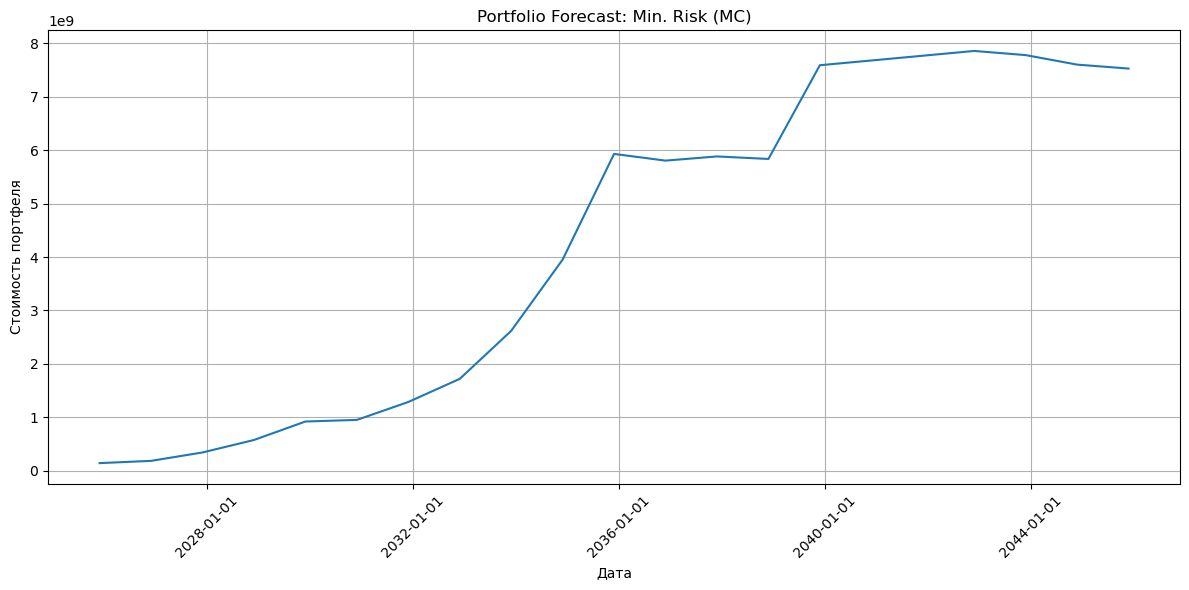

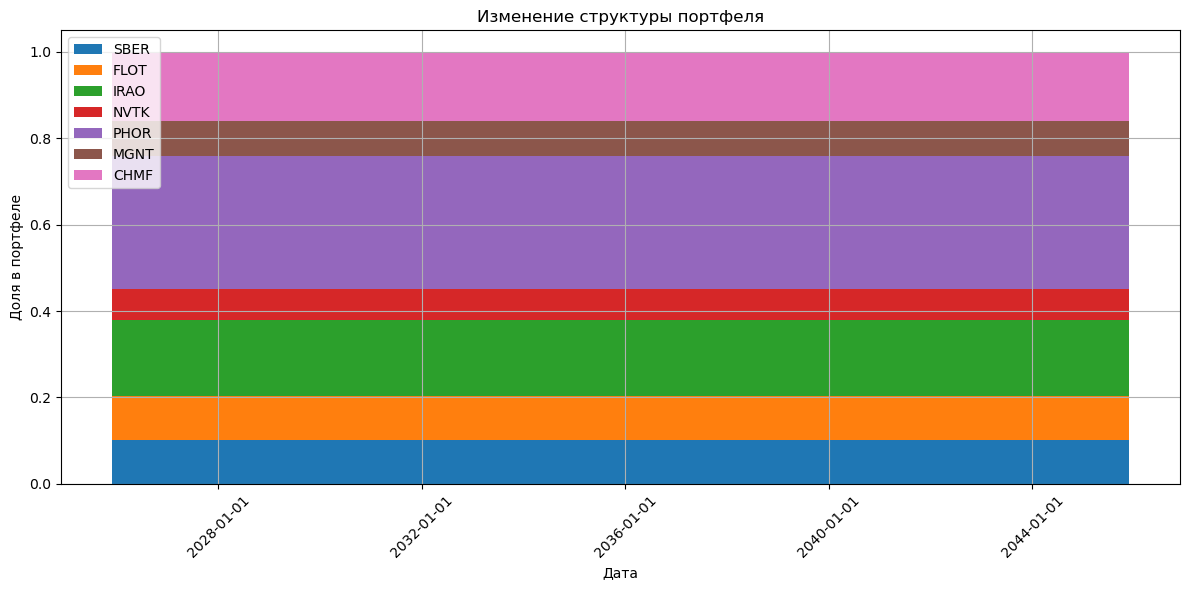

Max Drawdown (Min. Risk (MC)): 4.20%

Min. Risk (MC):
 Год  Доходность  Стоимость портфеля
2026   -0.015546        1.867682e+08
2027    0.483386        3.439204e+08
2028    0.483386        5.770378e+08
2029    0.483386        9.228410e+08
2030   -0.015546        9.528738e+08
2031    0.290574        1.287933e+09
2032    0.290574        1.720352e+09
2033    0.483386        2.618817e+09
2034    0.483386        3.951588e+09
2035    0.483386        5.928602e+09
2036   -0.028524        5.803289e+09
2037    0.005689        5.881639e+09
2038   -0.015546        5.834583e+09
2039    0.290574        7.588139e+09
2040    0.005689        7.676642e+09
2041    0.005689        7.765650e+09
2042    0.005689        7.855163e+09
2043   -0.015546        7.777427e+09
2044   -0.028524        7.599378e+09
2045   -0.015546        7.525618e+09


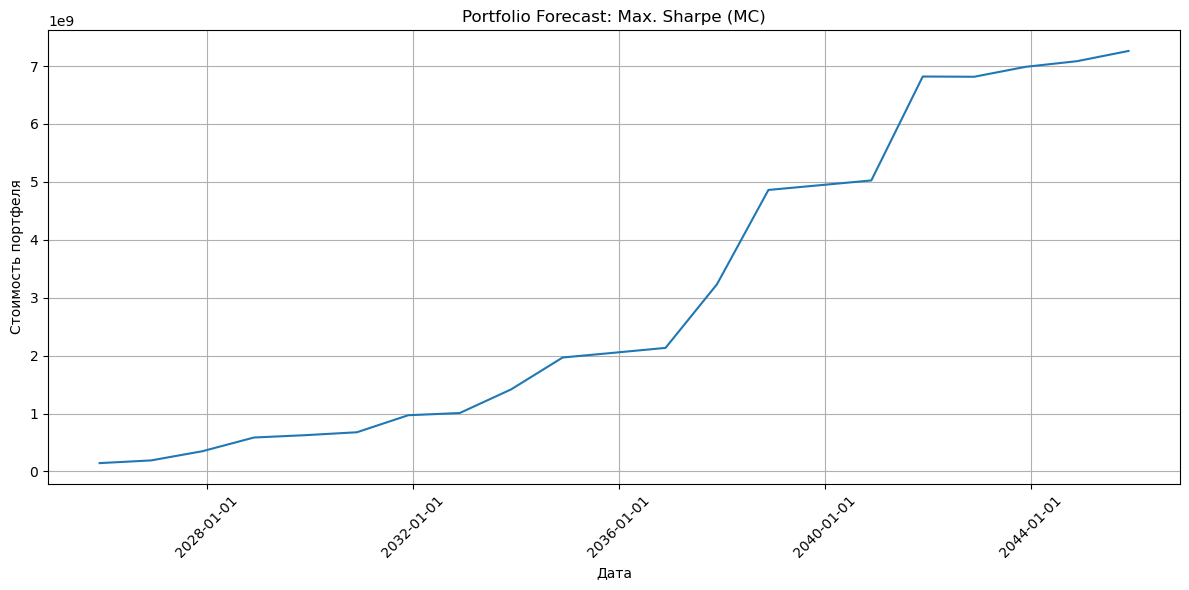

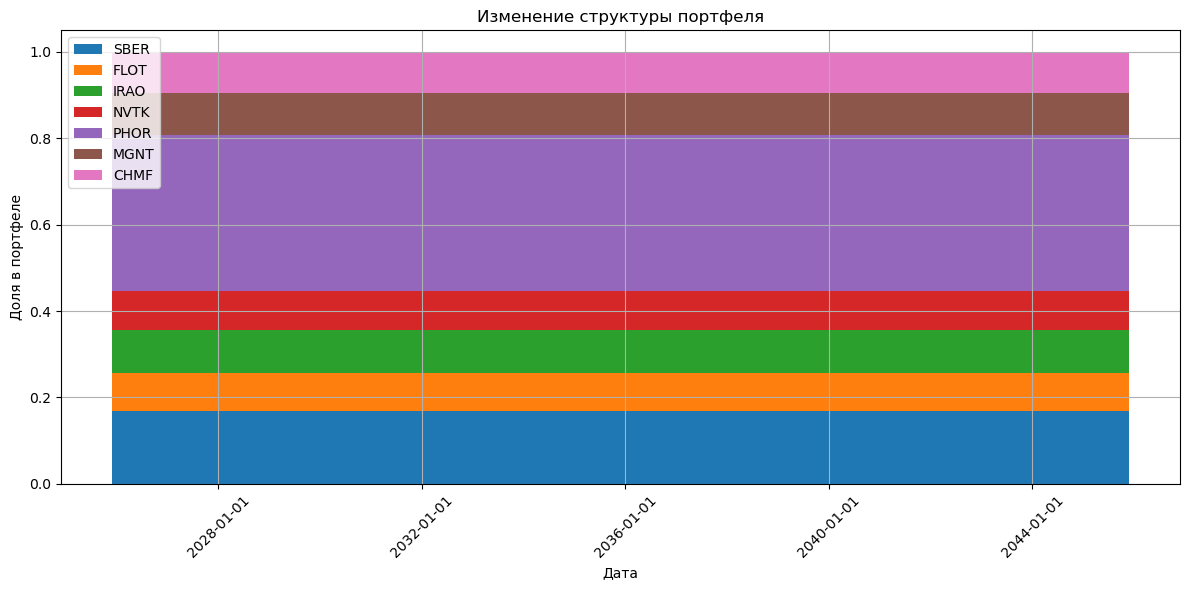

Max Drawdown (Max. Sharpe (MC)): 0.06%

Max. Sharpe (MC):
 Год  Доходность  Стоимость портфеля
2026    0.007453        1.911314e+08
2027    0.483293        3.503708e+08
2028    0.483293        5.865695e+08
2029   -0.007167        6.271226e+08
2030    0.007453        6.772124e+08
2031    0.345025        9.715012e+08
2032   -0.007167        1.009296e+09
2033    0.345025        1.418161e+09
2034    0.345025        1.968096e+09
2035    0.018445        2.050309e+09
2036    0.018445        2.134038e+09
2037    0.483293        3.232271e+09
2038    0.483293        4.861272e+09
2039    0.007453        4.942918e+09
2040    0.007453        5.025172e+09
2041    0.345025        6.819614e+09
2042   -0.007167        6.815497e+09
2043    0.018445        6.987119e+09
2044    0.007453        7.084608e+09
2045    0.018445        7.261194e+09


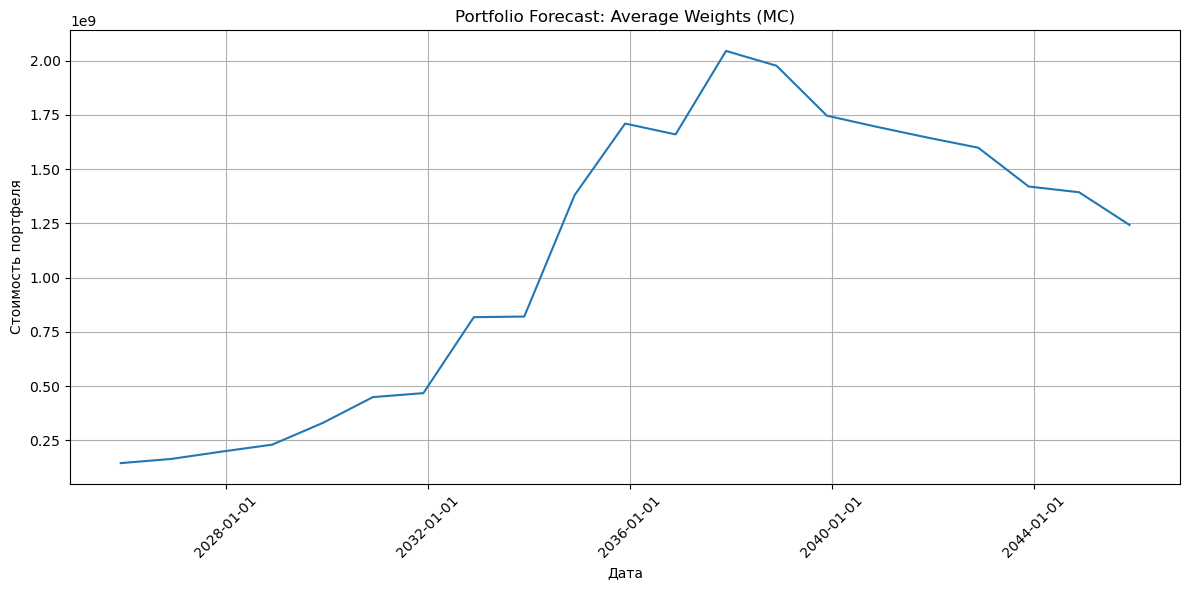

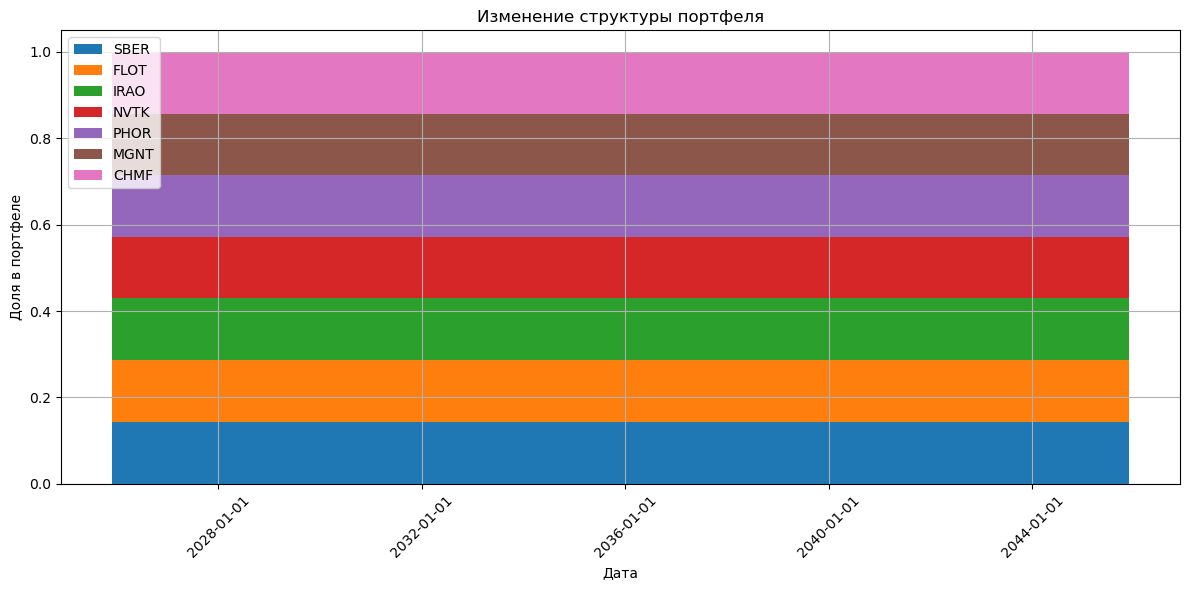

Max Drawdown (Average Weights (MC)): 39.24%

Average Weights (MC):
 Год  Доходность  Стоимость портфеля
2026   -0.136224        1.638735e+08
2027   -0.054173        1.976338e+08
2028   -0.054173        2.295652e+08
2029    0.199258        3.293705e+08
2030    0.199258        4.490628e+08
2031   -0.054173        4.673734e+08
2032    0.595555        8.176474e+08
2033   -0.048903        8.205377e+08
2034    0.595555        1.381140e+09
2035    0.199258        1.710406e+09
2036   -0.054173        1.660386e+09
2037    0.199258        2.045294e+09
2038   -0.054173        1.977131e+09
2039   -0.136224        1.746738e+09
2040   -0.054173        1.694750e+09
2041   -0.054173        1.645577e+09
2042   -0.054173        1.599069e+09
2043   -0.136224        1.420177e+09
2044   -0.048903        1.393602e+09
2045   -0.136224        1.242699e+09


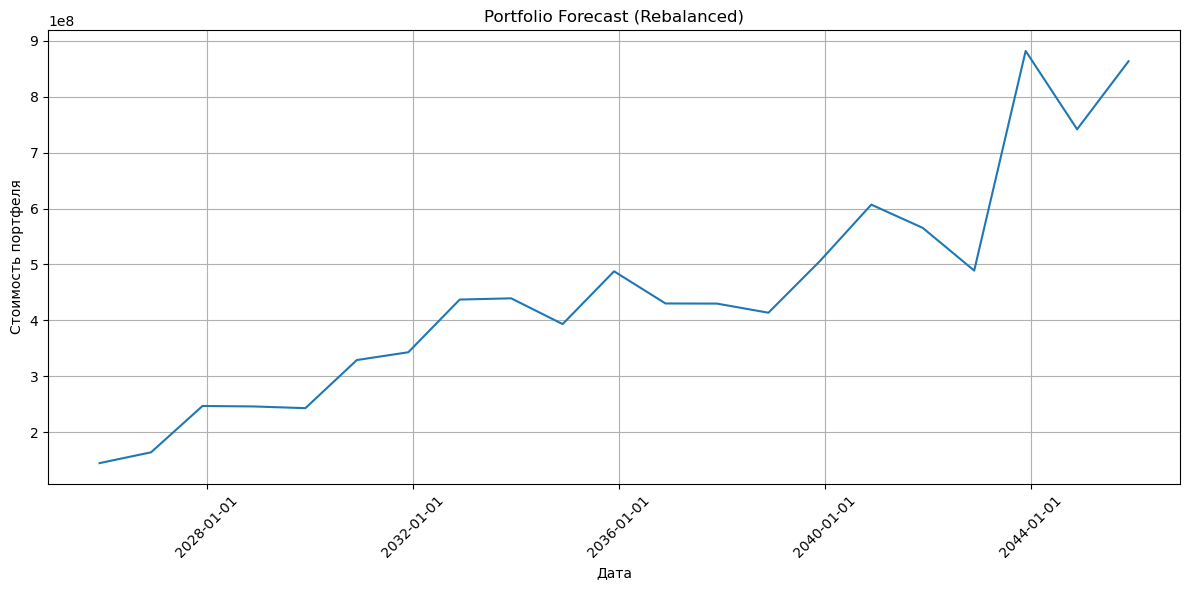

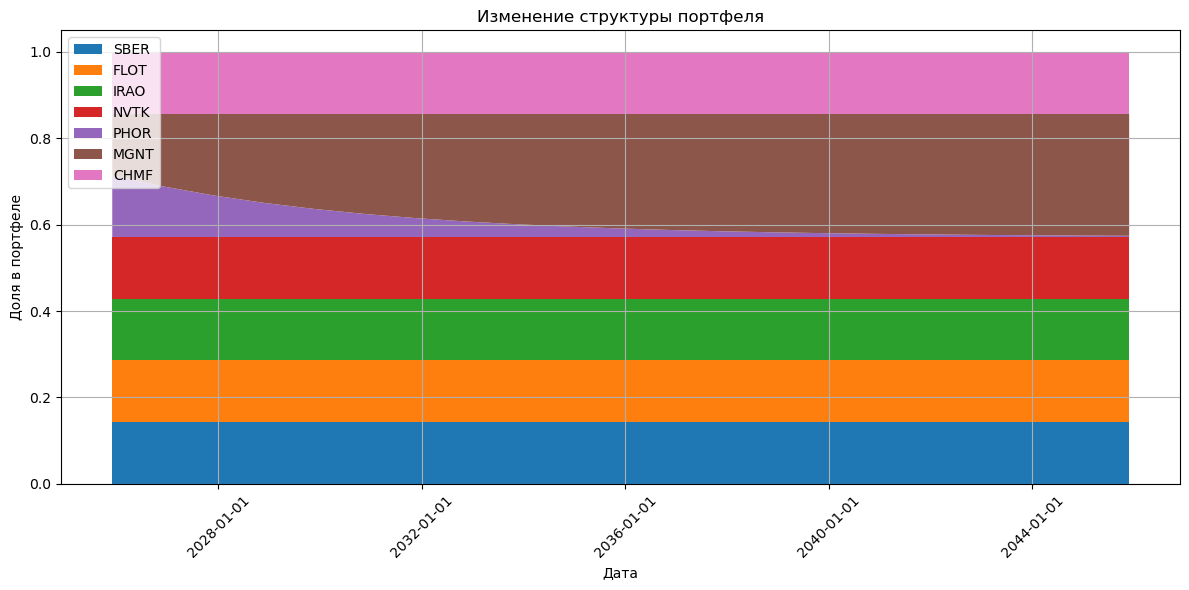

Max Drawdown (Rebalanced): 19.43%

Ребалансировка:
 Год  Доходность  Стоимость портфеля                                                                                                                                                 Веса
2026   -0.135774        1.639587e+08  [0.14285714285714285, 0.14285714285714285, 0.14285714285714285, 0.14285714285714285, 0.14285714285714285, 0.14285714285714285, 0.14285714285714285]
2027    0.180713        2.468147e+08  [0.14285714285714285, 0.14285714285714285, 0.14285714285714285, 0.14285714285714285, 0.11714285714285713, 0.16857142857142857, 0.14285714285714285]
2028   -0.157353        2.459642e+08  [0.14285714285714285, 0.14285714285714285, 0.14285714285714285, 0.14285714285714285, 0.09605714285714284, 0.18965714285714286, 0.14285714285714285]
2029   -0.165325        2.429272e+08  [0.14285714285714285, 0.14285714285714285, 0.14285714285714285, 0.14285714285714285, 0.07876685714285712, 0.20694742857142856, 0.14285714285714285]
2030    0.142256   

In [97]:
if __name__ == "__main__":

    df = load_data(DATA_FILE)
    if df is None:
        exit()

    selected_data = select_indices(df, SELECTED_INDICES_NAMES)
    if selected_data is None or selected_data.empty:
        print("Не выбраны индексы для анализа. Завершение работы.")
        exit()

    returns_data = select_date_range(selected_data, START_DATE_STR, END_DATE_STR)
    if returns_data is None or returns_data.empty:
        print("Не выбран диапазон дат. Завершение работы.")
        exit()


    returns = calculate_returns(returns_data)


    bounds = (MIN_ALLOCATION, MAX_ALLOCATION)



    markowitz_min_vol, markowitz_max_sharpe = markowitz_optimization(returns, risk_free_rate, bounds=bounds)


    monte_carlo_results = monte_carlo_simulation(returns, risk_free_rate, num_simulations=NUM_SIMULATIONS, bounds=bounds)


    mean_weights_mc = pd.DataFrame(monte_carlo_results[3:,:], index=returns.columns).mean(axis=1)
    mean_weights_mc /= mean_weights_mc.sum()
    mean_weights_dict = {'weights': mean_weights_mc.values}

    df_portfolios  = pd.DataFrame(monte_carlo_results.T, columns=['Volatility', 'Return', 'Sharpe'] + list(returns.columns))
    min_vol_port_mc = df_portfolios.iloc[df_portfolios['Volatility'].idxmin()]
    max_sharpe_port_mc = df_portfolios.iloc[df_portfolios['Sharpe'].idxmax()]

    plot_path = os.path.join(OUTPUT_FOLDER, "efficient_frontier.png")
    plot_efficient_frontier_and_portfolios(monte_carlo_results, mean_weights_dict, markowitz_min_vol, markowitz_max_sharpe, plot_path)

    forecast_start_date = datetime.strptime(FORECAST_START_DATE_STR, '%Y-%m-%d').date()

    optimal_portfolios = {
        "Min. Risk (Markowitz)": markowitz_min_vol['x'],
        "Max. Sharpe (Markowitz)": markowitz_max_sharpe['x'],
        "Min. Risk (MC)": min_vol_port_mc.iloc[3:].values,
        "Max. Sharpe (MC)": max_sharpe_port_mc.iloc[3:].values,
        "Average Weights (MC)": mean_weights_dict['weights']
    }


    forecast_results = {}
    for name, weights in optimal_portfolios.items():
        forecast_values, forecast_dates, yearly_results = forecast_portfolio(INITIAL_DEPOSIT, ANNUAL_CONTRIBUTION, FORECAST_YEARS, returns, weights, forecast_start_date)
        forecast_results[name] = {"dates": forecast_dates, "forecast": forecast_values, "weights": weights, "yearly_results": yearly_results}

        plot_portfolio_forecast(forecast_values, forecast_dates, f"Portfolio Forecast: {name}", os.path.join(OUTPUT_FOLDER, f"forecast_{name.replace(' ', '_')}.png"))

        initial_weights_plot = [weights] * len(forecast_dates) # Для графика структуры без ребалансировки
        plot_portfolio_structure(initial_weights_plot, forecast_dates, returns.columns, os.path.join(OUTPUT_FOLDER, f"portfolio_structure_{name.replace(' ', '_')}.png"))

        max_drawdown = calculate_max_drawdown(forecast_values)
        print(f"Max Drawdown ({name}): {max_drawdown:.2%}")

        print(f"\n{name}:")
        df_yearly = pd.DataFrame(yearly_results)
        print(df_yearly.to_string(index=False))


    if REBALANCING_ENABLED:
        initial_weights_rebalance = np.array([1/len(returns.columns)] * len(returns.columns))
        portfolio_values, dates, weights_history, yearly_results_rebalanced = rebalance_portfolio(INITIAL_DEPOSIT, ANNUAL_CONTRIBUTION, FORECAST_YEARS, returns, initial_weights_rebalance, RISK_AVERSION_DECAY, forecast_start_date)


        plot_portfolio_forecast(portfolio_values, dates, "Portfolio Forecast (Rebalanced)", os.path.join(OUTPUT_FOLDER, "forecast_rebalanced.png"))
        plot_portfolio_structure(weights_history, dates, returns.columns, os.path.join(OUTPUT_FOLDER, "portfolio_structure_rebalanced.png"))

        max_drawdown_rebalanced = calculate_max_drawdown(portfolio_values)
        print(f"Max Drawdown (Rebalanced): {max_drawdown_rebalanced:.2%}")
        print("\nРебалансировка:")
        df_yearly_rebalanced = pd.DataFrame(yearly_results_rebalanced)
        print(df_yearly_rebalanced.to_string(index=False))


    print(f"\nResults saved to: {OUTPUT_FOLDER}")